### DEFINING THE NUMBER OF LOCATIONS AND VEHICLES

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base,creator,tools,algorithms

num_locations=10
locations=[(random.randint(0,100),random.randint(0,100))for _ in range(num_locations)]
depot=(50,50)
num_vehicles=3

#GENETIC ALGO SETUP
creator.create("FitnessMin",base.Fitness,weights=(-1.0,-1.0))
creator.create("Individual",list,fitness=creator.FitnessMin)


### SETTING UP INDIVIDUALS AND POPULATION

In [11]:
toolbox=base.Toolbox()
toolbox.register("indices",random.sample,range(num_locations),num_locations)
toolbox.register("individual",tools.initIterate,creator.Individual,toolbox.indices)
toolbox.register("population",tools.initRepeat,list,toolbox.individual)

## FITNESS FUNCTIONS

def evalVRP(individual):
    total_distance=0
    distances=[]

    for i in range(num_vehicles):
        vehicle_route=[depot]+[locations[individual[j]] for j in range(i,len(individual),num_vehicles)]+[depot]
        vehicle_distance=sum(np.linalg.norm(np.array(vehicle_route[k+1])-np.array(vehicle_route[k])) for k in range(len(vehicle_route)-1))
        total_distance+=vehicle_distance
        distances.append(vehicle_distance)
    balance_penalty=np.std(distances)
    return total_distance,balance_penalty

toolbox.register("evaluate",evalVRP)
toolbox.register("mate",tools.cxPartialyMatched)
toolbox.register("mutate",tools.mutShuffleIndexes,indpb=0.05)
toolbox.register("select",tools.selTournament,tournsize=3)



### PLOTTING THE PATH AND RUNNING THE MAIN FUNCTION

gen	nevals	avg    	min    
0  	300   	318.079	1.12056
1  	220   	305.416	3.26851
2  	240   	302.835	4.39958
3  	229   	294.939	1.74276
4  	228   	290.442	3.91525
5  	218   	283.397	3.63062
6  	220   	281.655	2.42708
7  	232   	271.996	1.7691 
8  	223   	266.086	2.42708
9  	219   	257.247	2.42708
10 	251   	254.189	2.72368
11 	221   	238.879	3.22375
12 	221   	225.313	4.7579 
13 	212   	213.671	2.82472
14 	216   	207.668	6.83739
15 	222   	204.298	2.82472
16 	229   	199.08 	2.82472
17 	230   	197.736	2.82472
18 	228   	197.876	10.3866
19 	244   	195.971	4.7579 
20 	223   	195.126	2.82472
21 	222   	197.753	4.7579 
22 	223   	195.692	7.02669
23 	218   	196.124	2.82472
24 	240   	196.545	13.8487
25 	227   	196.106	4.7579 
26 	235   	194.997	9.2489 
27 	235   	196.974	2.82472
28 	235   	196.472	4.7579 
29 	240   	198.189	4.7579 
30 	235   	196.094	2.82472
31 	232   	195.399	2.82472
32 	229   	196.2  	2.82472
33 	243   	197.249	2.82472
34 	214   	197.392	1.00896
35 	234   	199.947	10.6819
3

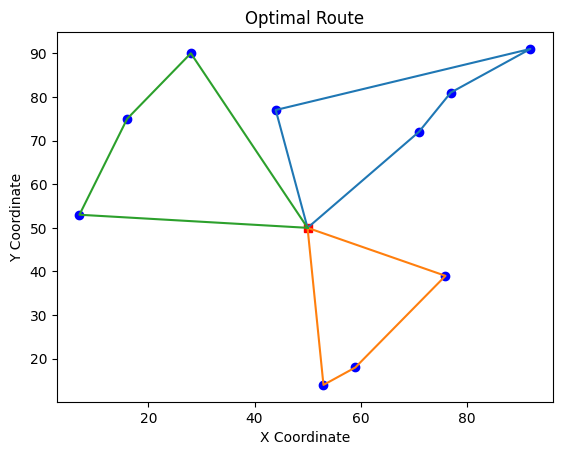

In [14]:
def plot_routes(individual, title="Routes"):
    plt.figure()
    # Plot locations as blue dots and the depot as a red square
    for (x, y) in locations:
        plt.plot(x, y, 'bo')
    plt.plot(depot[0], depot[1], 'rs')

    # Draw routes for each vehicle
    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]
        plt.plot(*zip(*vehicle_route), '-')

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.show()

def main():
    random.seed(42)  # Seed for reproducibility
    pop = toolbox.population(n=300)  # Generate initial population
    hof = tools.HallOfFame(1)  # Hall of Fame to store the best individual

    # Setup statistics to track
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)

    # Run the genetic algorithm
    algorithms.eaSimple(pop, toolbox, 0.7, 0.2, 300, stats=stats, halloffame=hof)

    # Plot the best route found
    plot_routes(hof[0], "Optimal Route")
    return pop, stats, hof

if __name__ == "__main__":
    main()